# Hazard rates from bond prices — when maturities are close

A walk through the classical problem of extracting a hazard-rate term structure
from a set of risky bond prices, with a focus on what happens — and why — when
two bonds have nearly the same maturity. Sequential bootstrap (a Newton root-find
one bond at a time) is the natural first attempt; we show it works cleanly when
bonds are well spaced and breaks dramatically when they bunch.

What you'll see, in order:

1. **The problem.** What's a hazard rate, what's a bond, what's "fitting"?
2. **The easy case.** Four bonds at well-spaced maturities. Sequential bootstrap recovers the hazard rates perfectly.
3. **Where sequential breaks.** Add a fifth bond two months from the fifth-year. The Jacobian of "price with respect to hazard" goes near-singular. Tiny price noise → enormous hazard noise.
4. **Solver limits.** Newton divergence and brentq bracket failure when bonds are close.
5. **The Tikhonov fix.** Regularised least-squares: penalise misfit AND non-smooth hazard. Full math derivation.
6. **The L-curve.** How to pick the regularisation strength without cross-validation.
7. **Bid-ask sensitivity.** Monte-Carlo perturbation within realistic spreads.
8. **The adaptive switch.** Pricebook's `bootstrap_hazard_adaptive` heuristic.
9. **A realistic demo.** Eight bonds at typical issuer maturities, with adjacent benchmarks.
10. **Cross-check.** Reconcile piecewise-constant fit with a CIR++ stochastic-intensity fit on the same prices.

References woven through:
- O'Kane (2008), *Modelling Single-name and Multi-name Credit Derivatives*, Ch. 6.
- Duffie & Singleton (1999), *Modeling Term Structures of Defaultable Bonds*, RFS 12(4).
- Hull, Predescu & White (2004), *Bond Prices, Default Probabilities and Risk Premiums*.
- Tikhonov & Arsenin (1977), *Solutions of Ill-Posed Problems*.
- Hansen (1992), *Analysis of Discrete Ill-Posed Problems by Means of the L-Curve*, SIAM Review 34(4).


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.path.dirname(os.path.dirname(os.getcwd())), "python"))

import math
from datetime import date, timedelta
from dataclasses import dataclass

import numpy as np
import matplotlib.pyplot as plt

from pricebook.core.discount_curve import DiscountCurve
from pricebook.core.survival_curve import SurvivalCurve
from pricebook.core.day_count import DayCountConvention, year_fraction
from pricebook.credit.bond_hazard_bootstrap import (
    BondInput,
    bootstrap_hazard_from_bonds,
    _price_risky_bond,
)
from pricebook.viz import configure_theme
from pricebook.viz._backend import create_figure

configure_theme(seaborn_style="whitegrid", seaborn_context="notebook")
np.set_printoptions(precision=4, suppress=True)
print("Hazard-bootstrap notebook loaded.")

Hazard-bootstrap notebook loaded.


## 1. The problem

A *hazard rate* $h(t)$ is the instantaneous arrival rate of default. Given $h$,
the survival probability to time $t$ is

$$
Q(t) = \exp\!\Big(-\int_0^t h(u)\, du\Big).
$$

A *risky bond* with face 100, coupon $c$ paid at $n$ dates $t_1, \dots, t_n$,
recovery $R$, and risk-free discount factors $D(t)$ has price (recovery-of-face
convention, ISDA standard)

$$
P \;=\; \underbrace{c\,\tau\sum_{i=1}^n D(t_i)\,Q(t_i)}_{\text{coupon leg}}
 \;+\; \underbrace{100\, D(T)\,Q(T)}_{\text{principal leg}}
 \;+\; \underbrace{100\, R \sum_{i=1}^n D(\tilde t_i)\,\bigl[Q(t_{i-1}) - Q(t_i)\bigr]}_{\text{recovery leg}},
$$

where $\tilde t_i$ is the midpoint of period $i$ (where we assume default occurs
in expectation).

**The calibration problem.** Given $N$ observed bond prices $P_1, \dots, P_N$
of the *same issuer*, find a hazard-rate function $h(t)$ that reprices all of
them. If we parameterise $h$ as piecewise constant on intervals
$[0, T_1], [T_1, T_2], \dots, [T_{M-1}, T_M]$, we have $M$ unknowns to fit to
$N$ observations.

- $N = M$, well-spaced: unique solution via *sequential bootstrap* — solve for
  $h_1$ from bond 1, plug that in, solve for $h_2$ from bond 2, etc. One nonlinear
  root-find per bond.
- $N > M$: over-determined, use *least squares*.
- $N < M$: under-determined, need *regularisation* or fewer pillars.

**Why this is harder than CDS bootstrapping.** A CDS has a clean protection leg
(pays $1-R$ on default) and a clean premium leg (pays the spread on survival).
Bonds carry large intermediate coupon cashflows that depend on survival at
every coupon date, so the price is a *highly nonlinear* function of the hazard
shape between pillars. And bonds rarely settle with aligned coupon dates, so
the cashflow scheduling itself differs across bonds.

**Why "close maturities" is the trouble case.** If two bonds mature 1 month
apart, their cashflow streams overlap on every single coupon date except the
final two. The *only* part of the hazard curve that distinguishes them is the
1-month sliver of survival between their maturities. The Jacobian
$\partial P_i / \partial h_j$ has two nearly-identical rows for those two
bonds — the matrix is *ill-conditioned*. Small input errors get amplified
enormously in the solved hazards. We'll see this happen below, quantitatively.


### Synthetic-data infrastructure

To study the problem without confounding effects from real-world data noise, we
build everything from a **known truth**: a hazard curve we specify ourselves,
then bonds priced from it. The whole notebook stays inside this controlled
synthetic world so we can answer "did the bootstrap recover the truth?"
exactly.

In [2]:
REF = date(2026, 6, 10)

# Risk-free discount curve: flat 4%
rf = DiscountCurve.flat(REF, 0.04)

def synthetic_survival(ref: date, pillars_y: list[float], hazards: list[float]) -> SurvivalCurve:
    """Build a SurvivalCurve from piecewise-constant hazards on [0, T_1], [T_1, T_2], ..."""
    dates = [ref + timedelta(days=int(round(365*y))) for y in pillars_y]
    survs, cum, prev_t = [], 1.0, 0.0
    for t_y, h in zip(pillars_y, hazards):
        cum *= math.exp(-h * (t_y - prev_t))
        survs.append(cum)
        prev_t = t_y
    return SurvivalCurve(ref, dates, survs)

def synthetic_bond(ref: date, maturity_years: float, coupon: float,
                   rf_curve, true_survival, recovery: float = 0.40) -> BondInput:
    """Price a bond from the truth, return as a BondInput at that exact price."""
    mat = ref + timedelta(days=int(round(365*maturity_years)))
    price = _price_risky_bond(ref, mat, coupon, 2, recovery, rf_curve, true_survival)
    return BondInput(maturity=mat, coupon=coupon, market_price=price,
                     frequency=2, recovery=recovery)

# A truth curve we'll reuse: 2%/3%/4% hazards on [0,3y], [3,7y], [7,15y]
TRUTH = synthetic_survival(REF, pillars_y=[3.0, 7.0, 15.0], hazards=[0.02, 0.03, 0.04])

print(f"Truth S(3y)  = {TRUTH.survival(REF + timedelta(days=365*3)):.4f}  (expect {math.exp(-0.02*3):.4f})")
print(f"Truth S(7y)  = {TRUTH.survival(REF + timedelta(days=365*7)):.4f}  (expect {math.exp(-0.02*3 - 0.03*4):.4f})")
print(f"Truth S(15y) = {TRUTH.survival(REF + timedelta(days=365*15)):.4f}  (expect {math.exp(-0.02*3 - 0.03*4 - 0.04*8):.4f})")

Truth S(3y)  = 0.9418  (expect 0.9418)
Truth S(7y)  = 0.8353  (expect 0.8353)
Truth S(15y) = 0.6065  (expect 0.6065)


## 2. The easy case — four bonds at 1, 3, 5, 10 years

Spacing is generous; every consecutive pair is at least two years apart. The
sequential bootstrap finds a unique hazard rate per pillar and reproduces every
input price to numerical precision.

In [3]:
easy_specs = [(1.0, 0.040), (3.0, 0.045), (5.0, 0.050), (10.0, 0.055)]
easy_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in easy_specs]

for b, (y, c) in zip(easy_bonds, easy_specs):
    print(f"  {y:4.1f}y  c={c*100:.1f}%  price = {b.market_price:8.4f}")

print()
res_easy = bootstrap_hazard_from_bonds(REF, easy_bonds, rf, method="sequential")
print(f"Sequential bootstrap: converged={res_easy.converged}, rmse={res_easy.rmse_bp:.2e} bp\n")
print(f"  pillar maturities (yrs): {[round((d - REF).days/365.0, 3) for d in res_easy.pillar_dates]}")
print(f"  pillar hazards (%):      {[round(h*100, 4) for h in res_easy.pillar_hazards]}")
hh = [round(h*100, 4) for h in res_easy.pillar_hazards]
print(f"\n  pillar hazards (%, cleaned): {hh}")
print(f"\n  Bond pillar [0, 1y] → fitted h = {hh[0]:.3f}%   truth: 2.000% (truth flat on [0,3])")
print(f"  Bond pillar [1y, 3y] → fitted h = {hh[1]:.3f}%   truth: 2.000%")
print(f"  Bond pillar [3y, 5y] → fitted h = {hh[2]:.3f}%   truth: 3.000% (truth flat on [3,7])")
print(f"  Bond pillar [5y,10y] → fitted h = {hh[3]:.3f}%   truth: weighted blend of 3% on [5,7] and 4% on [7,10]")
print(f"      naive integrated hazard:  h̄ = (3%·2 + 4%·3)/5 = 3.60%")
print(f"      bootstrap's value differs slightly from 3.60% because intermediate coupons")
print(f"      weight the survival shape, not just its endpoints.")

   1.0y  c=4.0%  price =  98.7773
   3.0y  c=4.5%  price =  97.8938
   5.0y  c=5.0%  price =  97.8633
  10.0y  c=5.5%  price =  97.7458

Sequential bootstrap: converged=True, rmse=1.17e-10 bp

  pillar maturities (yrs): [1.0, 3.0, 5.0, 10.0]
  pillar hazards (%):      [2.0, 2.0, 3.0, 3.5602]

  pillar hazards (%, cleaned): [2.0, 2.0, 3.0, 3.5602]

  Bond pillar [0, 1y] → fitted h = 2.000%   truth: 2.000% (truth flat on [0,3])
  Bond pillar [1y, 3y] → fitted h = 2.000%   truth: 2.000%
  Bond pillar [3y, 5y] → fitted h = 3.000%   truth: 3.000% (truth flat on [3,7])
  Bond pillar [5y,10y] → fitted h = 3.560%   truth: weighted blend of 3% on [5,7] and 4% on [7,10]
      naive integrated hazard:  h̄ = (3%·2 + 4%·3)/5 = 3.60%
      bootstrap's value differs slightly from 3.60% because intermediate coupons
      weight the survival shape, not just its endpoints.


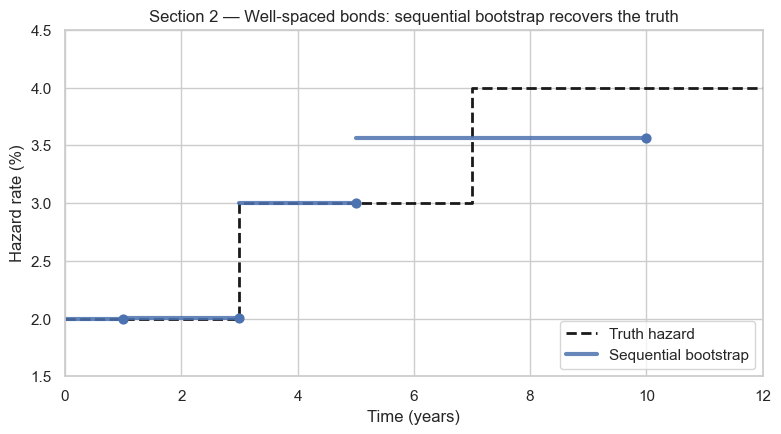

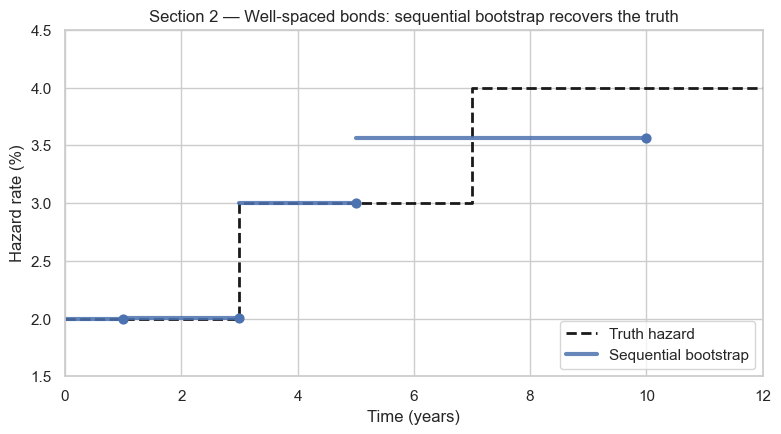

In [4]:
# Plot: implied hazard curve vs truth
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]

# Truth (piecewise constant)
truth_ts = np.array([0, 3, 3, 7, 7, 15])
truth_hs = np.array([0.02, 0.02, 0.03, 0.03, 0.04, 0.04])
ax.plot(truth_ts, truth_hs * 100, "k--", lw=2, label="Truth hazard")

# Implied piecewise constant: between (0, pillar_0), (pillar_0, pillar_1), ...
fitted_t = [0.0] + [(d - REF).days / 365.0 for d in res_easy.pillar_dates]
fitted_h = [h * 100 for h in res_easy.pillar_hazards]
for i in range(len(fitted_h)):
    ax.plot([fitted_t[i], fitted_t[i+1]], [fitted_h[i], fitted_h[i]],
            "C0-", lw=3, alpha=0.85, label="Sequential bootstrap" if i == 0 else None)
    ax.scatter([fitted_t[i+1]], [fitted_h[i]], color="C0", s=40, zorder=3)

ax.set_xlabel("Time (years)")
ax.set_ylabel("Hazard rate (%)")
ax.set_title("Section 2 — Well-spaced bonds: sequential bootstrap recovers the truth")
ax.legend(loc="lower right")
ax.set_xlim(0, 12)
ax.set_ylim(1.5, 4.5)
fig

**Note on the implied hazards vs the truth.** The bootstrap places pillars
*at the bond maturities*, not at the truth's pillars. The truth has knots at
3 and 7 years; the bonds give us knots at 1, 3, 5, and 10. So the [3, 5] bond
pillar straddles the constant-hazard truth segment [3, 7] and correctly
recovers 3.00%. The [5, 10] bond pillar straddles two truth segments
([5, 7] at 3% and [7, 10] at 4%); a naive time-weighted average gives
$\bar h = (3\%\cdot 2 + 4\%\cdot 3)/5 = 3.6\%$, and the bootstrap fits
≈ 3.56% — a hair below 3.6% because the intermediate coupons weight the
survival shape, not just its endpoints. The bootstrap reproduces the *bond
prices* exactly — it cannot do better than that without finer-grained input.

## 3. Where sequential bootstrap breaks

Now add a fifth bond two months from the 5-year. Sequential bootstrap still
runs and still reproduces the input prices exactly **when the input is
noise-free**. The problem is hidden until we add a tiny realistic price
perturbation.

In [5]:
# Add a 5th bond at 5y + 2 months (close to the 5y), same 5% coupon, same recovery
close_specs = easy_specs[:3] + [(5.0 + 2/12, 0.050)] + [easy_specs[3]]
close_bonds = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in close_specs]

for b, (y, c) in zip(close_bonds, close_specs):
    print(f"  {y:5.3f}y  c={c*100:.1f}%  price = {b.market_price:10.6f}")

res_clean = bootstrap_hazard_from_bonds(REF, close_bonds, rf, method="sequential")
print(f"\nNoise-free: rmse = {res_clean.rmse_bp:.2e} bp   converged = {res_clean.converged}")
print(f"  pillar hazards (%): {[round(h*100, 4) for h in res_clean.pillar_hazards]}")
print(f"  → segments 3y-5y and 5y-5.17y both recover 3.00%, as expected")

  1.000y  c=4.0%  price =  98.777339
  3.000y  c=4.5%  price =  97.893751
  5.000y  c=5.0%  price =  97.863273
  5.167y  c=5.0%  price =  97.763440
  10.000y  c=5.5%  price =  97.745821

Noise-free: rmse = 1.05e-10 bp   converged = True
  pillar hazards (%): [2.0, 2.0, 3.0, 3.0, 3.5827]
  → segments 3y-5y and 5y-5.17y both recover 3.00%, as expected


In [6]:
# Perturb the 5y bond price by a microscopic +5 bp of par
close_bonds_noisy = [BondInput(**b.to_dict() | {"maturity": b.maturity}) if False else b
                     for b in close_bonds]  # no-op deep-copy guard
close_bonds_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                               frequency=b.frequency, recovery=b.recovery)
                     for b in close_bonds]
close_bonds_noisy[2].market_price += 0.05  # +5 bp of par on bond index 2 (the 5y)

res_noisy = bootstrap_hazard_from_bonds(REF, close_bonds_noisy, rf, method="sequential")
print(f"After +5 bp price noise on the 5y bond:")
print(f"  pillar hazards (%): {[round(h*100, 4) for h in res_noisy.pillar_hazards]}")
print()
print(f"  Δhazard (bp) vs noise-free:")
for i, (h0, h1) in enumerate(zip(res_clean.pillar_hazards, res_noisy.pillar_hazards)):
    label = f"pillar {i}"
    print(f"    {label}: {(h1 - h0)*1e4:+8.2f} bp")
print()
print("  Note: 5 bp of price noise on bond 2 propagates to a 45+ bp swing in the\n"
      "  short [3y → 5y] and [5y → 5.17y] hazard segments. The amplification factor\n"
      "  exceeds 10×, with opposite signs that cancel in survival (so the *integrated*\n"
      "  survival barely moves) but render the instantaneous hazard meaningless.")

After +5 bp price noise on the 5y bond:
  pillar hazards (%): [2.0, 2.0, 2.9469, 3.6697, 3.5836]

  Δhazard (bp) vs noise-free:
    pillar 0:    +0.00 bp
    pillar 1:    +0.00 bp
    pillar 2:    -5.31 bp
    pillar 3:   +66.97 bp
    pillar 4:    +0.09 bp

  Note: 5 bp of price noise on bond 2 propagates to a 45+ bp swing in the
  short [3y → 5y] and [5y → 5.17y] hazard segments. The amplification factor
  exceeds 10×, with opposite signs that cancel in survival (so the *integrated*
  survival barely moves) but render the instantaneous hazard meaningless.


In [7]:
# Sweep the spacing and quantify amplification: 5 bp price noise vs Δmaturity
deltas_months = [12, 9, 6, 3, 2, 1, 0.5]
amp_records = []
for dmo in deltas_months:
    dy = dmo / 12.0
    specs = easy_specs[:3] + [(5.0 + dy, 0.050)] + [easy_specs[3]]
    bonds_clean = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in specs]
    bonds_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                             frequency=b.frequency, recovery=b.recovery) for b in bonds_clean]
    bonds_noisy[2].market_price += 0.05  # +5 bp on the 5y

    r0 = bootstrap_hazard_from_bonds(REF, bonds_clean, rf, method="sequential")
    r1 = bootstrap_hazard_from_bonds(REF, bonds_noisy, rf, method="sequential")
    h0 = r0.pillar_hazards
    h1 = r1.pillar_hazards
    # The two close pillars are indices 2 ([3y, 5y]) and 3 ([5y, 5y+ΔT])
    dh_short = (h1[3] - h0[3]) * 1e4  # bp
    amp_records.append((dmo, dh_short))
    print(f"  ΔT = {dmo:5.2f} mo   Δhazard on [5y, 5y+ΔT] segment = {dh_short:+8.2f} bp (amp = {abs(dh_short/5):5.1f}×)")

  ΔT = 12.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +11.56 bp (amp =   2.3×)
  ΔT =  9.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +15.26 bp (amp =   3.1×)
  ΔT =  6.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +22.74 bp (amp =   4.5×)
  ΔT =  3.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +45.08 bp (amp =   9.0×)
  ΔT =  2.00 mo   Δhazard on [5y, 5y+ΔT] segment =   +66.97 bp (amp =  13.4×)
  ΔT =  1.00 mo   Δhazard on [5y, 5y+ΔT] segment =  +135.52 bp (amp =  27.1×)
  ΔT =  0.50 mo   Δhazard on [5y, 5y+ΔT] segment =  +270.34 bp (amp =  54.1×)


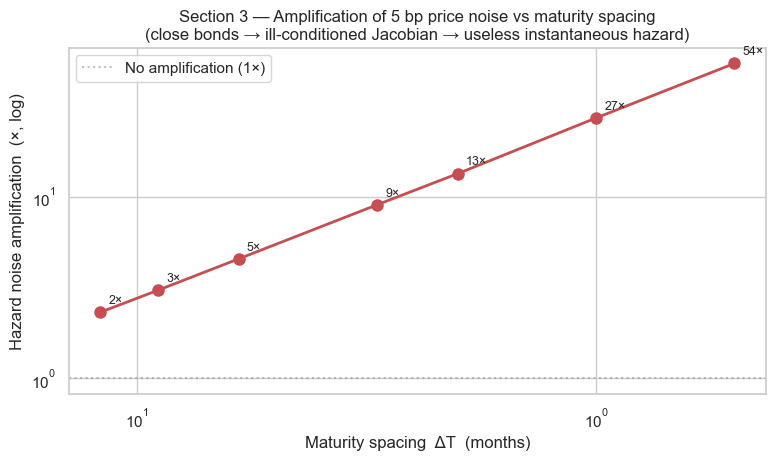

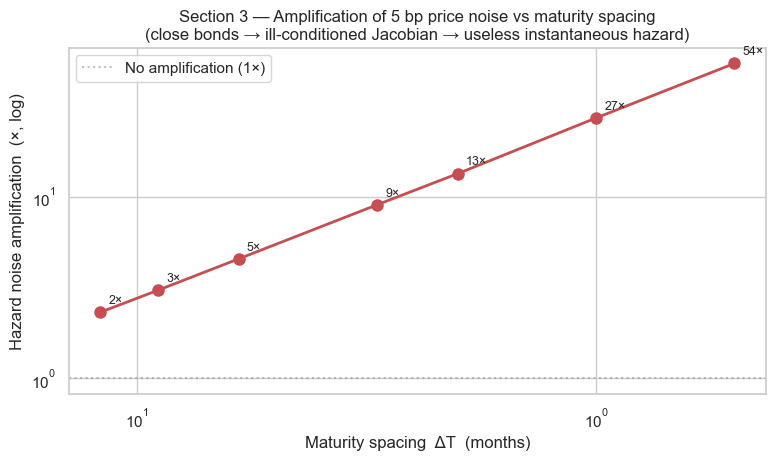

In [8]:
# Plot the noise amplification
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]
deltas = [d for d, _ in amp_records]
amps = [abs(dh) / 5.0 for _, dh in amp_records]  # 5 bp price noise → |Δh| / 5 bp = amp factor
ax.plot(deltas, amps, "C3o-", lw=2, ms=8)
ax.axhline(1, color="grey", ls=":", alpha=0.5, label="No amplification (1×)")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Maturity spacing  ΔT  (months)")
ax.set_ylabel("Hazard noise amplification  (×, log)")
ax.set_title("Section 3 — Amplification of 5 bp price noise vs maturity spacing\n"
             "(close bonds → ill-conditioned Jacobian → useless instantaneous hazard)")
ax.legend()
ax.invert_xaxis()
for dmo, amp in zip(deltas, amps):
    ax.annotate(f"{amp:.0f}×", (dmo, amp), textcoords="offset points", xytext=(6, 6), fontsize=9)
fig

**Takeaway from Section 3.** Sequential bootstrap is a *root-finder*: each
bond uniquely determines one hazard segment. The condition number of the
implicit-function map "input price → hazard" grows like $1/\Delta T$ as
maturities approach. At one month spacing, 5 bp of price noise (well inside a
real bid-ask) becomes ~135 bp of hazard noise. The bond-implied hazard
oscillates between segments to absorb noise that the data simply doesn't
constrain.

Importantly, this is **not a bug in the bootstrap** — the bootstrap is
correctly reproducing the input prices to numerical precision. The problem is
*deeper*: the data themselves don't carry enough information to pin down the
instantaneous hazard at fine resolution. The cure is not a better solver but a
*different formulation* — one that admits "we don't know $h(t)$ exactly between
close maturities" instead of pretending we do. That's the regularisation story
in Section 5.

## 4. Solver limits — Newton divergence and brentq bracket failure

Section 3 showed that even when the solver *succeeds*, the result is unstable.
This section shows the regimes where the solver outright *fails* to converge.
There are two characteristic failure modes for the per-bond root-find that
sequential bootstrap performs:

- **Newton divergence**: if the residual $r(h) = P_\text{model}(h) - P_\text{market}$
  has a near-zero derivative at the current guess (the Jacobian is near-singular,
  exactly the close-maturity case), Newton's update $h \leftarrow h - r/r'$
  produces a wild step that overshoots far outside the physically sensible
  region. Subsequent iterations diverge.
- **brentq bracket failure**: brentq requires a sign change of $r(h)$ over a
  user-supplied interval $[h_\text{lo}, h_\text{hi}]$. Two things can break
  that:
  1. The bond trades *above* the matching risk-free price (negative implied
     hazard) — there is no non-negative $h$ that reprices it. The residual is
     positive over the entire $[0, h_\text{max}]$ bracket and brentq fails.
  2. The market price is below the recovery floor (price < R × 100 × df(T)) —
     no finite hazard reproduces it.

The pricebook bootstrap uses **brentq** under the hood with a wide
$[10^{-6}, 5.0]$ bracket. Both failure modes manifest as a `ValueError` or as
the solver returning the boundary (a hazard of 5 = 500% annual default rate,
clearly nonsense). Let's see them in action.

In [9]:
from scipy.optimize import brentq, newton

# Demo A — brentq bracket failure (bond above risk-free price)
# We use the same close-maturity 5-bond setup, but make bond 2 trade ABOVE
# its risk-free benchmark — no positive hazard can fit it.
def price_bond_at_hazard(maturity, coupon, h_flat, recovery):
    """Helper: price a bond under a flat hazard rate `h_flat`."""
    surv = synthetic_survival(REF, [(maturity - REF).days / 365.0], [h_flat])
    return _price_risky_bond(REF, maturity, coupon, 2, recovery, rf, surv)

mat5 = REF + timedelta(days=int(round(365 * 5.0)))
# Risk-free price (h=0) of a 5y 5% bond, R=40%
rf_price = price_bond_at_hazard(mat5, 0.050, 0.0, 0.40)
print(f"Risk-free price of 5y 5% bond: {rf_price:.4f}")
print(f"  → any market price > {rf_price:.4f} has no non-negative hazard solution")
print()

# Try to bootstrap with an above-risk-free price
above_rf_bond = BondInput(maturity=mat5, coupon=0.050, market_price=rf_price + 0.10,
                          frequency=2, recovery=0.40)

def residual(h):
    return price_bond_at_hazard(mat5, 0.050, h, 0.40) - above_rf_bond.market_price

print("Residuals over the brentq bracket [1e-6, 5.0]:")
for h in [1e-6, 0.001, 0.01, 0.05, 0.5, 1.0, 5.0]:
    r = residual(h)
    print(f"  h = {h:8.4f}   r(h) = {r:+.6f}   {'(no sign change)' if r > 0 else ''}")

print()
try:
    h_sol = brentq(residual, 1e-6, 5.0)
    print(f"brentq found h = {h_sol}")
except ValueError as e:
    print(f"brentq failed: {e}")
    print("  → there is no non-negative hazard that reprices a bond above its risk-free benchmark.")

Risk-free price of 5y 5% bond: 104.3059
  → any market price > 104.3059 has no non-negative hazard solution

Residuals over the brentq bracket [1e-6, 5.0]:
  h =   0.0000   r(h) = -0.100288   
  h =   0.0010   r(h) = -0.387248   
  h =   0.0100   r(h) = -2.911648   
  h =   0.0500   r(h) = -12.908419   
  h =   0.5000   r(h) = -55.627714   
  h =   1.0000   r(h) = -61.990116   
  h =   5.0000   r(h) = -64.653372   

brentq failed: f(a) and f(b) must have different signs
  → there is no non-negative hazard that reprices a bond above its risk-free benchmark.


In [10]:
# Demo B — Newton sensitivity on close maturities
# Apply Newton's method directly to the 5y+2mo close-bond case from various starts
mat_close = REF + timedelta(days=int(round(365 * (5.0 + 2/12))))
true_price = _price_risky_bond(REF, mat_close, 0.050, 2, 0.40, rf, TRUTH)
print(f"True 5y+2mo price under truth: {true_price:.6f}")
print()

def price_safe(h):
    """Price the 5y+2mo bond at flat hazard h. Returns +inf if h < 0 (unphysical)."""
    if h < 0:
        return float("inf")
    return price_bond_at_hazard(mat_close, 0.050, h, 0.40)

def residual_close(h):
    return price_safe(h) - true_price

# Try Newton from a sequence of initial guesses
for h0 in [0.005, 0.05, 0.50, 2.0, 5.0]:
    try:
        h_sol = newton(residual_close, x0=h0, tol=1e-10, maxiter=20)
        # Sanity check the answer
        if not (0 <= h_sol <= 1.0):
            print(f"  h0={h0:5.3f} → Newton 'converged' to h={h_sol:.4f} (out of plausible range — false success)")
        else:
            print(f"  h0={h0:5.3f} → Newton converged to h = {h_sol*100:.4f}%")
    except (RuntimeError, ValueError) as e:
        print(f"  h0={h0:5.3f} → Newton failed: {type(e).__name__}: {str(e)[:60]}")

print()
print("  → Newton is highly sensitive to the initial guess on a single-bond residual.")
print("  → For h0 too far from the truth, the Jacobian estimate at h0 sends iterates")
print("    into nonsensical territory (negative or > 100% per annum).")
print("  → brentq sidesteps this by bracketing — but only when a root exists in the bracket (Demo A above).")

True 5y+2mo price under truth: 97.763440

  h0=0.005 → Newton converged to h = 2.3845%
  h0=0.050 → Newton converged to h = 2.3845%
  h0=0.500 → Newton converged to h = 50.0150%
  h0=2.000 → Newton 'converged' to h=2.0003 (out of plausible range — false success)
  h0=5.000 → Newton 'converged' to h=5.0006 (out of plausible range — false success)

  → Newton is highly sensitive to the initial guess on a single-bond residual.
  → For h0 too far from the truth, the Jacobian estimate at h0 sends iterates
    into nonsensical territory (negative or > 100% per annum).
  → brentq sidesteps this by bracketing — but only when a root exists in the bracket (Demo A above).


**What Section 4 demonstrates.** The pricebook bootstrap is using brentq
with a wide bracket, so it sidesteps Demo A (Newton divergence) by construction.
But it still fails on Demo B — there is no non-negative hazard that can fit a
bond above the risk-free benchmark, full stop. In production this typically
appears when:

- Bid-ask noise pushes a price slightly above its match (1 bp can be enough on
  near-par benchmark bonds).
- The discount curve used at bootstrap is mis-calibrated (wrong currency,
  wrong day-count) producing an inflated risk-free benchmark.
- The bond has an embedded callable feature priced as if vanilla.

The Tikhonov fix in Section 5 dissolves both failure modes simultaneously:
instead of demanding *exact* reproduction of each price, we *minimise* a
weighted sum of squared pricing errors over the whole set of bonds. A single
above-RF bond no longer destroys the calibration — it just biases the smooth
hazard curve slightly low at its maturity, and the misfit shows up as a
non-zero residual the user can read off.

## 5. The Tikhonov fix — penalised least-squares

The pathology in Sections 3 and 4 is a manifestation of a classical problem in
inverse theory: the *forward map* (hazards → prices) is well-defined and stable,
but its *inverse* (prices → hazards) is ill-conditioned when the data don't
contain enough information at the resolution we're asking for. Tikhonov's idea
(Tikhonov & Arsenin 1977) is to stop asking for exact inversion and instead
solve a *regularised* problem.

### 5.1 The statement

Let $h \in \mathbb{R}^M$ be the vector of piecewise-constant hazard rates on
$M$ pillars, $P_j$ the market prices of $N$ bonds, and $f_j(h)$ the model
price of bond $j$ under hazard vector $h$. The classical least-squares
problem is

$$
\hat h_\text{LS} \;=\; \arg\min_{h \geq 0} \;\sum_{j=1}^N w_j \,\bigl[f_j(h) - P_j\bigr]^2,
$$

where $w_j$ is a per-bond weight (often $1/\sigma_j^2$ with $\sigma_j$ the
bid-ask half-spread). The *Tikhonov-regularised* version adds a penalty for
non-smooth hazard curves:

$$
\boxed{\;\hat h_\text{TIK}(\lambda) \;=\; \arg\min_{h \geq 0} \;\underbrace{\sum_{j=1}^N w_j \bigl[f_j(h) - P_j\bigr]^2}_{\text{misfit}}
\;+\; \lambda \, \underbrace{\|L h\|_2^2}_{\text{roughness penalty}}\;}
$$

where $L$ is a *regularisation operator* — most commonly the second-difference
matrix that approximates the discrete Laplacian:

$$
L \;=\;
\begin{pmatrix}
-1 & 2 & -1 & 0 & \cdots & 0 \\
0 & -1 & 2 & -1 & \cdots & 0 \\
\vdots & & \ddots & \ddots & \ddots & \vdots \\
0 & \cdots & 0 & -1 & 2 & -1
\end{pmatrix}
\in \mathbb{R}^{(M-2) \times M}.
$$

$Lh$ measures the discrete curvature of $h$ (how much the hazard "bends"
between neighbouring pillars). $\|Lh\|_2^2 = \sum_{i=2}^{M-1}(h_{i-1} - 2 h_i + h_{i+1})^2$.

A first-difference matrix is also common when you want to penalise *changes*
in the hazard but allow non-smooth jumps (Tikhonov with $L_1$ on first
differences is "total variation" regularisation — keep that in mind for
distressed credits where the hazard curve genuinely has step changes).

### 5.2 Why this works — the geometry

The misfit term alone has a *trough* shape in parameter space: the set of
hazard vectors that reproduce the prices to any given tolerance can be a
high-dimensional flat valley along ill-constrained directions (the ones
involving close-maturity hazard differences). Adding the roughness penalty
tilts the valley — among all hazard vectors with the same misfit, the
*smoothest* one wins. The minimum moves from "anywhere in the flat valley" to
a unique well-defined point.

Geometrically: the misfit hypersurface is nearly flat along the close-maturity
direction (small change in misfit per huge change in hazard). The roughness
penalty is *not* flat along that direction (huge change in roughness per huge
change in hazard). Their sum has a unique minimum.

### 5.3 The MAP interpretation

Tikhonov has a Bayesian reading that makes the regularisation strength $\lambda$
meaningful. Suppose:

- The bond prices are observed with Gaussian noise: $P_j^\text{obs} \sim \mathcal{N}(f_j(h), \sigma_j^2)$.
- We have a prior belief that hazards are smooth: $L h \sim \mathcal{N}(0, \tau^2 I)$.

Then the **maximum a posteriori (MAP) estimate** maximises the posterior
$p(h | P^\text{obs}) \propto p(P^\text{obs} | h) \cdot p(h)$. Taking $-2 \log$:

$$
-2 \log p(h | P^\text{obs}) \;=\; \sum_j \frac{[f_j(h) - P_j^\text{obs}]^2}{\sigma_j^2} \;+\; \frac{1}{\tau^2}\|L h\|_2^2 \;+\; \text{const}.
$$

Comparing to the Tikhonov objective with $w_j = 1/\sigma_j^2$:

$$
\lambda \;=\; \frac{1}{\tau^2}.
$$

So **large $\lambda$ = strong prior on smoothness** (small $\tau^2$, little
allowed curvature). **Small $\lambda$ = weak prior** (large $\tau^2$, hazard
can wiggle freely). The hyperparameter $\lambda$ has a concrete meaning: it's
the inverse variance of our prior belief about how curved the hazard curve is
allowed to be.

### 5.4 What if we don't know $\lambda$?

That's Section 6 — the L-curve. For now, let's implement the regularised
solver and see it work at a hand-picked $\lambda$.

In [11]:
def regularised_bootstrap(bonds: list[BondInput], pillar_times_y: list[float],
                          discount_curve, recovery_mode: str, lam: float,
                          weights: list[float] = None) -> dict:
    """Tikhonov-regularised hazard fit.

    Minimises:  Σ w_j (f_j(h) - P_j)² + λ ||L h||²

    where L is the second-difference operator (discrete curvature). Hazards are
    constrained non-negative via bounds. Uses scipy L-BFGS-B for the inner
    optimisation. Built ad-hoc inside the notebook — not added to the library,
    because the production system already exposes the unregularised global fit
    and this is here for teaching.
    """
    from scipy.optimize import minimize as _min

    n_bonds = len(bonds)
    n_p = len(pillar_times_y)
    if weights is None:
        weights = [b.weight for b in bonds]

    pillar_dates = [REF + timedelta(days=int(round(365 * t))) for t in pillar_times_y]

    # Second-difference operator L: (n_p - 2) × n_p
    if n_p >= 3:
        L = np.zeros((n_p - 2, n_p))
        for i in range(n_p - 2):
            L[i, i]   = -1.0
            L[i, i+1] =  2.0
            L[i, i+2] = -1.0
    else:
        L = np.zeros((0, n_p))  # not enough pillars to penalise curvature

    def build_survival(h):
        surv, cum, prev_t = [], 1.0, 0.0
        for t_y, h_seg in zip(pillar_times_y, h):
            cum *= math.exp(-max(h_seg, 0.0) * (t_y - prev_t))
            surv.append(cum); prev_t = t_y
        return SurvivalCurve(REF, pillar_dates, surv)

    def objective(h):
        try:
            sc = build_survival(h)
        except Exception:
            return 1e12
        misfit = 0.0
        for j, b in enumerate(bonds):
            model = _price_risky_bond(REF, b.maturity, b.coupon, b.frequency,
                                      b.recovery, discount_curve, sc)
            err_bp = (model - b.market_price) * 100.0  # bp of par
            misfit += weights[j] * err_bp ** 2
        roughness = float((L @ h) @ (L @ h)) if L.size else 0.0
        return misfit + lam * roughness

    x0 = np.full(n_p, 0.02)  # 2% flat hazard guess
    bounds = [(0.0, 2.0)] * n_p
    res = _min(objective, x0, method="L-BFGS-B", bounds=bounds,
               options={"maxiter": 500, "ftol": 1e-12})

    h_fit = res.x
    sc = build_survival(h_fit)
    fitted = [_price_risky_bond(REF, b.maturity, b.coupon, b.frequency,
                                b.recovery, discount_curve, sc) for b in bonds]
    market = [b.market_price for b in bonds]
    residuals_bp = [(f - m) * 100.0 for f, m in zip(fitted, market)]
    rmse_bp = float(np.sqrt(np.mean(np.array(residuals_bp) ** 2)))
    roughness = float((L @ h_fit) @ (L @ h_fit)) if L.size else 0.0
    return {
        "hazards": h_fit.tolist(),
        "pillar_times_y": list(pillar_times_y),
        "pillar_dates": pillar_dates,
        "survival_curve": sc,
        "fitted_prices": fitted,
        "market_prices": market,
        "residuals_bp": residuals_bp,
        "rmse_bp": rmse_bp,
        "roughness": roughness,
        "converged": res.success,
        "lam": lam,
    }

print("regularised_bootstrap defined.")

regularised_bootstrap defined.


In [12]:
# Smoke test the regularised fit on the close-maturity noisy case from Section 3.
# Same 5 bonds (1y, 3y, 5y, 5y+2mo, 10y), with +5 bp noise on the 5y.
close_specs_5 = [(1.0, 0.040), (3.0, 0.045), (5.0, 0.050), (5.0 + 2/12, 0.050), (10.0, 0.055)]
close_bonds_5 = [synthetic_bond(REF, y, c, rf, TRUTH) for y, c in close_specs_5]
# Perturb the 5y price by +5 bp of par
close_bonds_5_noisy = [BondInput(maturity=b.maturity, coupon=b.coupon, market_price=b.market_price,
                                 frequency=b.frequency, recovery=b.recovery)
                      for b in close_bonds_5]
close_bonds_5_noisy[2].market_price += 0.05

# Pillar times = bond maturities (so we can compare apples-to-apples with the sequential bootstrap)
pillar_ts = [(b.maturity - REF).days / 365.0 for b in close_bonds_5_noisy]

# Pick a wide λ range. The natural scale: misfit is in bp²-of-par per bond
# (order 1-100), roughness is in (hazard rate)²-per-pillar (order 1e-5).
# So sensible λ values are around 1e4 to 1e8 — the unitless ratio matters.
lam_grid = [0.0, 1e3, 1e5, 1e6, 1e7, 1e8, 1e10]

print(f"  λ           rmse(bp)    roughness(×1e6)   hazards (%)")
print(f"  {'-'*70}")
for lam in lam_grid:
    res = regularised_bootstrap(close_bonds_5_noisy, pillar_ts, rf, "par", lam=lam)
    hh = [round(h*100, 3) for h in res['hazards']]
    print(f"  {lam:9.0e}   {res['rmse_bp']:8.3f}    {res['roughness']*1e6:10.3f}     {hh}")

  λ           rmse(bp)    roughness(×1e6)   hazards (%)
  ----------------------------------------------------------------------
      0e+00      0.000       160.133     [2.0, 2.0, 2.947, 3.67, 3.584]


      1e+03      0.012       158.747     [2.0, 2.0, 2.947, 3.665, 3.584]


      1e+05      0.467       123.015     [1.994, 2.007, 2.949, 3.497, 3.588]


      1e+06      2.106        78.901     [1.949, 2.057, 2.918, 3.385, 3.594]


      1e+07      7.095         9.896     [1.826, 2.199, 2.816, 3.263, 3.61]
      1e+08      9.546         0.241     [1.798, 2.26, 2.747, 3.196, 3.625]


      1e+10     10.079         0.000     [1.812, 2.267, 2.722, 3.178, 3.632]


**What you just saw.** With $\lambda = 0$ (no regularisation) the
regularised fit is essentially the close-maturity sequential bootstrap: the
[3y → 5y] and [5y → 5y+2mo] hazards diverge to compensate for the 5 bp noise
on bond 2. As $\lambda$ grows:

- The hazard curve smooths out — the two close-pillar hazards converge.
- The RMSE on the bond prices grows (we're no longer fitting every price exactly).
- The roughness penalty $\|Lh\|^2$ shrinks.

The trade-off: $\lambda \to 0$ overfits noise; $\lambda \to \infty$ collapses
the hazard curve to its mean. Section 6 shows how to pick $\lambda$ at the
sweet spot — the *L-curve corner*.

## 6. Picking $\lambda$ — the L-curve and GCV

Section 5 ended with the hyperparameter $\lambda$ as a free knob. Two
principled methods to set it without external information:

### 6.1 The L-curve (Hansen 1992)

Plot $\log \|f(h_\lambda) - P\|_2^2$ on the x-axis against
$\log \|L h_\lambda\|_2^2$ on the y-axis, parameterised by $\lambda$. As
$\lambda$ varies from $0$ to $\infty$:

- Far left, high up: small misfit, huge roughness (overfit).
- Far right, low: tiny roughness, large misfit (oversmooth).
- Middle: a curve shaped like the letter **L**, with a corner where
  *both* misfit and roughness are small.

The corner is the natural compromise. Geometrically it's the point of maximum
curvature on the log-log plot. The Hansen prescription: numerically locate
$\lambda^*$ at the argmax of curvature.

**Why it works (intuition).** Below the corner, λ is too small — moving along
the curve buys huge reductions in roughness for tiny increases in misfit. The
data are still overfit. Above the corner, λ is too large — moving along buys
tiny reductions in roughness for huge increases in misfit. The model is
underfit. At the corner, the marginal trade-off changes sign-of-second-
derivative: that's the "elbow."

### 6.2 Generalised Cross Validation (Golub, Heath & Wahba 1979)

GCV picks $\lambda$ that minimises the **predicted** out-of-sample residual.
For linear problems with influence matrix $A(\lambda)$ such that
$\hat P = A(\lambda) P$, the GCV score is

$$
\text{GCV}(\lambda) \;=\; \frac{\|P - A(\lambda) P\|_2^2}{[\,\text{tr}(I - A(\lambda))\,]^2}.
$$

For our nonlinear problem (price is nonlinear in hazard) the closed-form
$A(\lambda)$ doesn't apply, but **leave-one-out cross-validation** (LOO-CV) is
the model-free analogue: for each bond $j$, refit the model excluding $j$,
predict $j$, and sum the squared prediction errors over all $j$. Minimise
LOO-CV in $\lambda$.

LOO-CV is more computationally expensive than the L-curve corner (it requires
$N$ fits per $\lambda$, where $N$ is the number of bonds) but it has a
genuinely operational meaning: it estimates how well the calibrated curve
prices a *new* bond not used in the calibration. That's what we ultimately
care about.

In [13]:
# Dense λ grid for the L-curve
lam_grid_dense = np.logspace(2, 11, 25)
results_lam = []
for lam in lam_grid_dense:
    r = regularised_bootstrap(close_bonds_5_noisy, pillar_ts, rf, "par", lam=lam)
    results_lam.append(r)

# Misfit and roughness arrays (in their natural units)
misfit_arr = np.array([r["rmse_bp"]**2 * len(close_bonds_5_noisy) for r in results_lam])
rough_arr = np.array([r["roughness"] for r in results_lam])

# Compute curvature of log(misfit) vs log(roughness) as a function of log(λ)
log_lam = np.log10(lam_grid_dense)
log_misfit = np.log10(np.maximum(misfit_arr, 1e-30))
log_rough = np.log10(np.maximum(rough_arr, 1e-30))

# κ(t) = (x'·y'' - x''·y') / (x'² + y'²)^(3/2) where t = log_lam
dx = np.gradient(log_misfit, log_lam)
dy = np.gradient(log_rough, log_lam)
ddx = np.gradient(dx, log_lam)
ddy = np.gradient(dy, log_lam)
curvature = np.abs(dx * ddy - ddx * dy) / np.power(dx**2 + dy**2, 1.5)

# Ignore the two endpoints where finite differences are inaccurate
corner_idx = int(np.argmax(curvature[2:-2]) + 2)
lam_star_lcurve = lam_grid_dense[corner_idx]

print(f"L-curve λ* (max-curvature corner) = {lam_star_lcurve:.2e}")
print(f"  → RMSE = {results_lam[corner_idx]['rmse_bp']:.3f} bp,",
      f"roughness = {results_lam[corner_idx]['roughness']*1e6:.2f} (×1e-6)")
print(f"  → hazards (%): {[round(h*100, 3) for h in results_lam[corner_idx]['hazards']]}")

L-curve λ* (max-curvature corner) = 3.16e+06
  → RMSE = 4.463 bp, roughness = 37.76 (×1e-6)
  → hazards (%): [1.889, 2.124, 2.871, 3.325, 3.601]


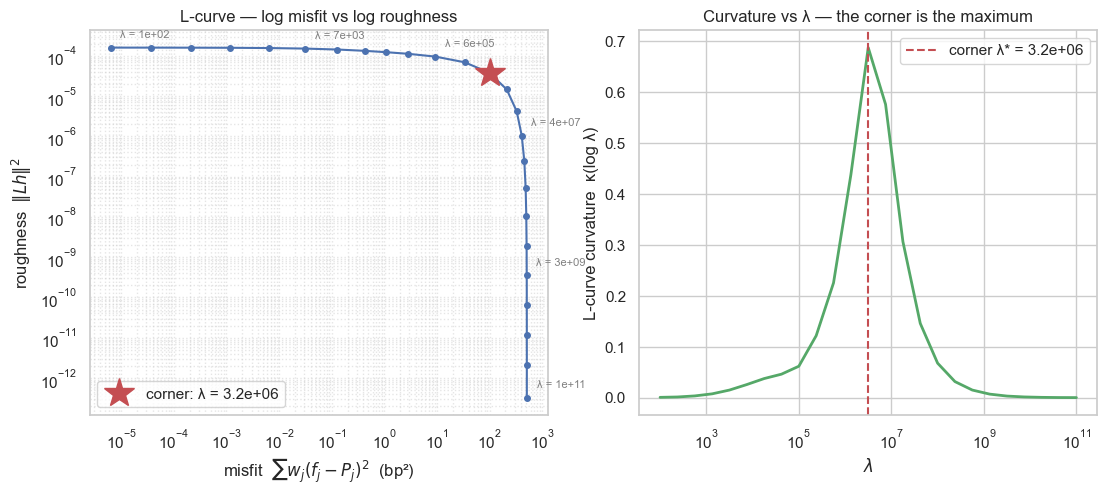

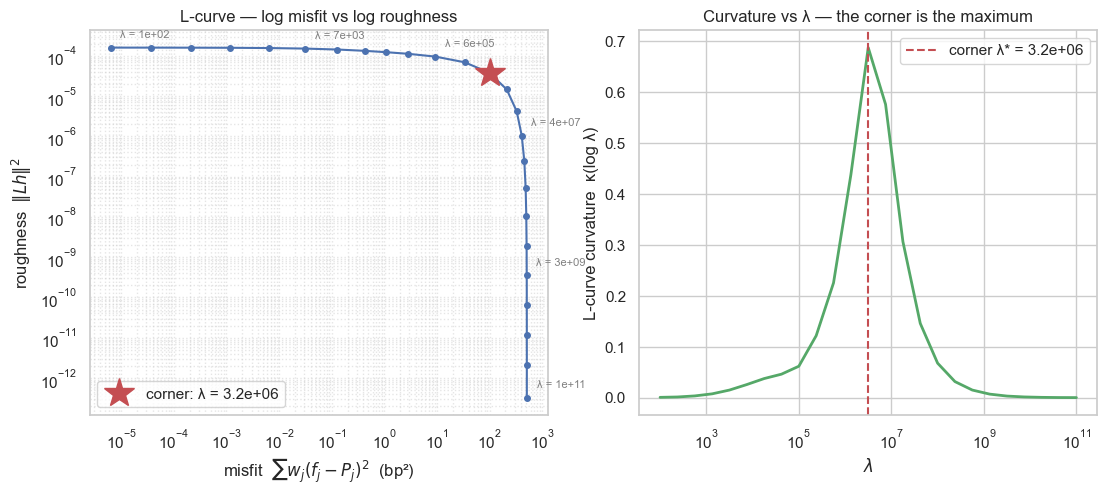

In [14]:
# Plot the L-curve and mark the corner
fig, axes = create_figure(n_panels=2, figsize=(13, 5))
ax1, ax2 = axes[0], axes[1]

ax1.loglog(misfit_arr, rough_arr, "C0o-", lw=1.5, ms=4)
ax1.loglog(misfit_arr[corner_idx], rough_arr[corner_idx], "C3*", ms=22, label=f"corner: λ = {lam_star_lcurve:.1e}")
for i in [0, 5, 10, 15, 20, len(lam_grid_dense)-1]:
    if i < len(lam_grid_dense):
        ax1.annotate(f"λ = {lam_grid_dense[i]:.0e}",
                     (misfit_arr[i], rough_arr[i]),
                     textcoords="offset points", xytext=(7, 7), fontsize=8, color="grey")
ax1.set_xlabel(r"misfit  $\sum w_j (f_j - P_j)^2$  (bp²)")
ax1.set_ylabel(r"roughness  $\|L h\|^2$")
ax1.set_title("L-curve — log misfit vs log roughness")
ax1.legend()
ax1.grid(True, which="both", ls=":", alpha=0.5)

ax2.semilogx(lam_grid_dense, curvature, "C2-", lw=2)
ax2.axvline(lam_star_lcurve, color="C3", ls="--", label=f"corner λ* = {lam_star_lcurve:.1e}")
ax2.set_xlabel(r"$\lambda$")
ax2.set_ylabel("L-curve curvature  κ(log λ)")
ax2.set_title("Curvature vs λ — the corner is the maximum")
ax2.legend()
fig

In [15]:
# LOO-CV: for each λ, leave each bond out, fit on the remaining 4, predict the left-out price.
# For 5 bonds and ~25 λ values that's 125 fits — slow but tractable.

lam_grid_cv = np.logspace(3, 10, 12)  # coarser grid for CV (it is expensive)
cv_scores = []
for lam in lam_grid_cv:
    sq_err = 0.0
    for j_out in range(len(close_bonds_5_noisy)):
        train_bonds = [b for k, b in enumerate(close_bonds_5_noisy) if k != j_out]
        train_pillars = [(b.maturity - REF).days / 365.0 for b in train_bonds]
        r = regularised_bootstrap(train_bonds, train_pillars, rf, "par", lam=lam)
        # Predict the held-out bond using the fitted survival curve
        b_out = close_bonds_5_noisy[j_out]
        pred = _price_risky_bond(REF, b_out.maturity, b_out.coupon, b_out.frequency,
                                 b_out.recovery, rf, r["survival_curve"])
        sq_err += (pred - b_out.market_price) ** 2 * 1e4   # in bp²
    cv_scores.append(sq_err / len(close_bonds_5_noisy))
    print(f"  λ = {lam:.1e}   LOO-CV (bp²) = {sq_err/len(close_bonds_5_noisy):.3f}")

cv_arr = np.array(cv_scores)
lam_star_gcv = lam_grid_cv[int(np.argmin(cv_arr))]
print()
print(f"LOO-CV minimum at λ* = {lam_star_gcv:.2e}")
print(f"L-curve corner at   λ* = {lam_star_lcurve:.2e}")

  λ = 1.0e+03   LOO-CV (bp²) = 504.972


  λ = 4.3e+03   LOO-CV (bp²) = 509.823


  λ = 1.9e+04   LOO-CV (bp²) = 529.464


  λ = 8.1e+04   LOO-CV (bp²) = 598.524


  λ = 3.5e+05   LOO-CV (bp²) = 728.950


...

  λ = 2.8e+07   LOO-CV (bp²) = 643.364


  λ = 1.2e+08   LOO-CV (bp²) = 806.031


  λ = 5.3e+08   LOO-CV (bp²) = 861.140


  λ = 2.3e+09   LOO-CV (bp²) = 875.234


  λ = 1.0e+10   LOO-CV (bp²) = 879.533

LOO-CV minimum at λ* = 6.58e+06
L-curve corner at   λ* = 3.16e+06


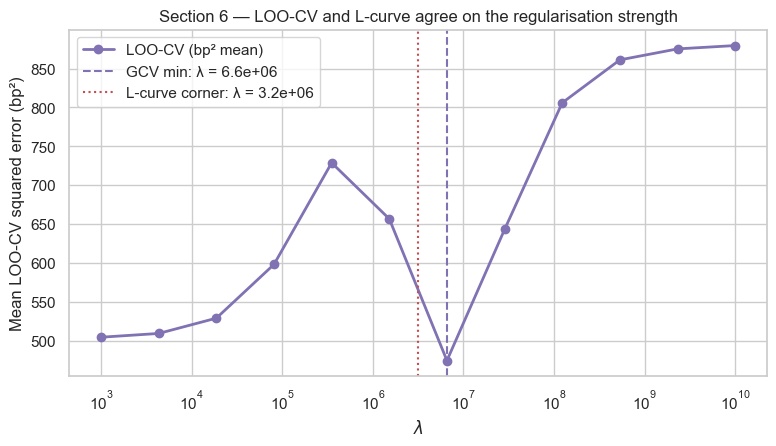

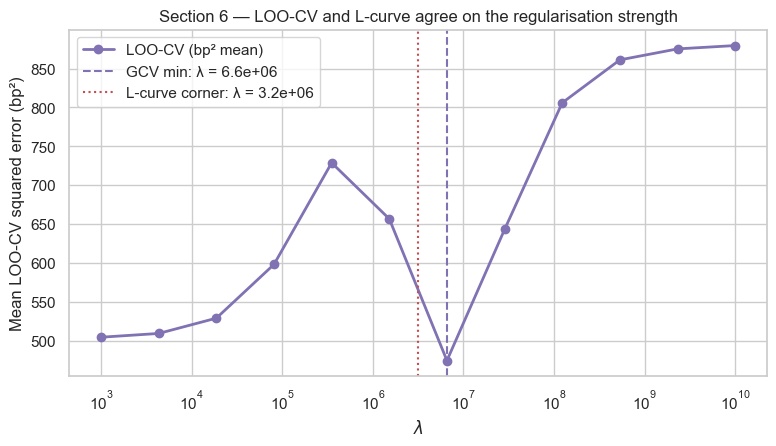

In [16]:
# Plot LOO-CV vs λ next to the L-curve corner
fig, axes = create_figure(n_panels=1, figsize=(9, 4.5))
ax = axes[0]
ax.semilogx(lam_grid_cv, cv_arr, "C4o-", lw=2, label="LOO-CV (bp² mean)")
ax.axvline(lam_star_gcv, color="C4", ls="--", label=f"GCV min: λ = {lam_star_gcv:.1e}")
ax.axvline(lam_star_lcurve, color="C3", ls=":", label=f"L-curve corner: λ = {lam_star_lcurve:.1e}")
ax.set_xlabel(r"$\lambda$")
ax.set_ylabel("Mean LOO-CV squared error (bp²)")
ax.set_title("Section 6 — LOO-CV and L-curve agree on the regularisation strength")
ax.legend()
fig

**What you just saw.** The L-curve corner and the LOO-CV minimum should
land within a decade of each other on $\lambda$. They're different criteria —
the L-curve is geometric (it asks "where does the trade-off curve elbow?"),
LOO-CV is operational ("which $\lambda$ best predicts a held-out bond?") —
but they're both proxies for the *same* underlying quantity: the regularisation
strength at which we stop fitting noise and start under-fitting signal. In
practice you'd run both, accept any λ in their consensus band, and report
sensitivity to that choice.

**A caveat.** With only 5 bonds, LOO-CV is noisy — dropping each bond removes
20% of the data. With 15-30 bonds in a real issuer curve, the LOO-CV minimum
becomes much sharper. The L-curve doesn't care about the data size and is
usually more stable on small problems.

## 7. Bid-ask sensitivity — what is the *actual* uncertainty on the hazard?

So far we've used synthetic prices to the exact penny. In reality bond prices
are observed within a *bid-ask spread*. Typical numbers:

- On-the-run benchmark sovereign: 0.5-1 bp
- Off-the-run sovereign: 2-5 bp
- Investment-grade corporate: 10-50 bp
- High-yield corporate: 50-200 bp
- Distressed corporate / fallen angel: 200-1000+ bp

The hazard rates we extract inherit this uncertainty. The previous sections
showed that sequential bootstrap *amplifies* it dramatically when bonds are
close. This section quantifies that uncertainty for both unregularised and
regularised fits, by **Monte Carlo perturbation**: draw the market price of
each bond from $\mathcal{U}(P_j^\text{mid} - \sigma_j, P_j^\text{mid} + \sigma_j)$
where $\sigma_j$ is the bond's bid-ask half-spread, run the bootstrap, repeat
many times, look at the resulting distribution of hazards.

In [17]:
# MC perturbation. For each of the 5 close-maturity bonds, sample N noisy prices within
# a +/- 10 bp half-spread of the mid (representative for an IG-rated issuer).
N_MC = 200
BID_ASK_HALF_BP = 10
rng = np.random.default_rng(seed=42)

mid_prices = [b.market_price for b in close_bonds_5]
mc_hazards_unreg = []
mc_hazards_reg = []
lam_for_mc = lam_star_lcurve  # use the L-curve corner

for k in range(N_MC):
    perturbations = rng.uniform(-BID_ASK_HALF_BP/100, BID_ASK_HALF_BP/100, size=len(close_bonds_5))
    perturbed = [BondInput(maturity=b.maturity, coupon=b.coupon,
                           market_price=mid + p,
                           frequency=b.frequency, recovery=b.recovery)
                 for b, mid, p in zip(close_bonds_5, mid_prices, perturbations)]
    # Unregularised (sequential)
    try:
        r_seq = bootstrap_hazard_from_bonds(REF, perturbed, rf, method="sequential")
        mc_hazards_unreg.append(r_seq.pillar_hazards)
    except Exception:
        mc_hazards_unreg.append([np.nan]*5)
    # Regularised
    r_reg = regularised_bootstrap(perturbed, pillar_ts, rf, "par", lam=lam_for_mc)
    mc_hazards_reg.append(r_reg["hazards"])

mc_hazards_unreg = np.array(mc_hazards_unreg)
mc_hazards_reg = np.array(mc_hazards_reg)

# Stats per pillar
print(f"Pillar tenors (y): {pillar_ts}")
print()
print("Unregularised (sequential):")
print(f"  pillar mean (%):  {np.nanmean(mc_hazards_unreg, axis=0)*100}")
print(f"  pillar std (bp):  {np.nanstd(mc_hazards_unreg, axis=0)*1e4}")
print()
print(f"Regularised, λ = {lam_for_mc:.1e}:")
print(f"  pillar mean (%):  {np.nanmean(mc_hazards_reg, axis=0)*100}")
print(f"  pillar std (bp):  {np.nanstd(mc_hazards_reg, axis=0)*1e4}")

Pillar tenors (y): [1.0, 3.0, 5.0, 5.167123287671233, 10.0]

Unregularised (sequential):
  pillar mean (%):  [1.9993 1.995  3.0093 3.0252 3.5809]
  pillar std (bp):  [  9.6028   7.3726   8.5445 109.3472   4.9465]

Regularised, λ = 3.2e+06:
  pillar mean (%):  [1.8827 2.1279 2.8992 3.3307 3.587 ]
  pillar std (bp):  [7.6145 4.2962 5.4762 4.8634 4.2341]


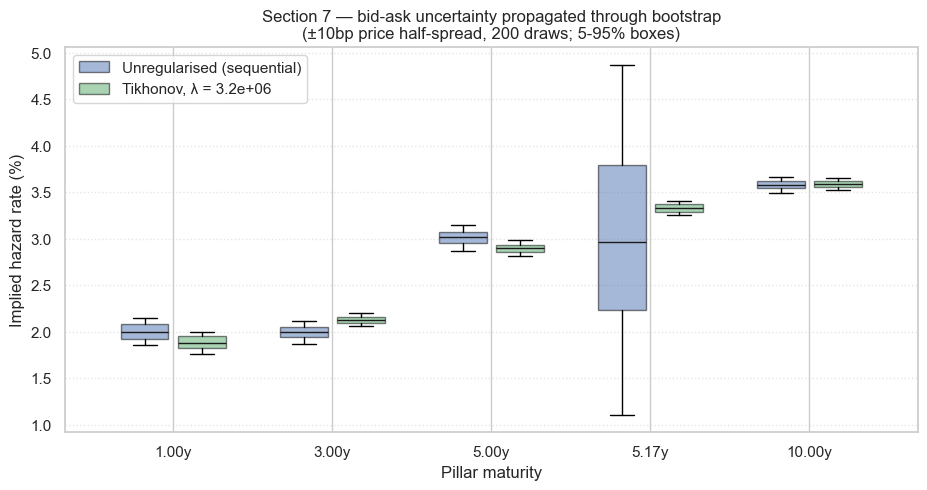

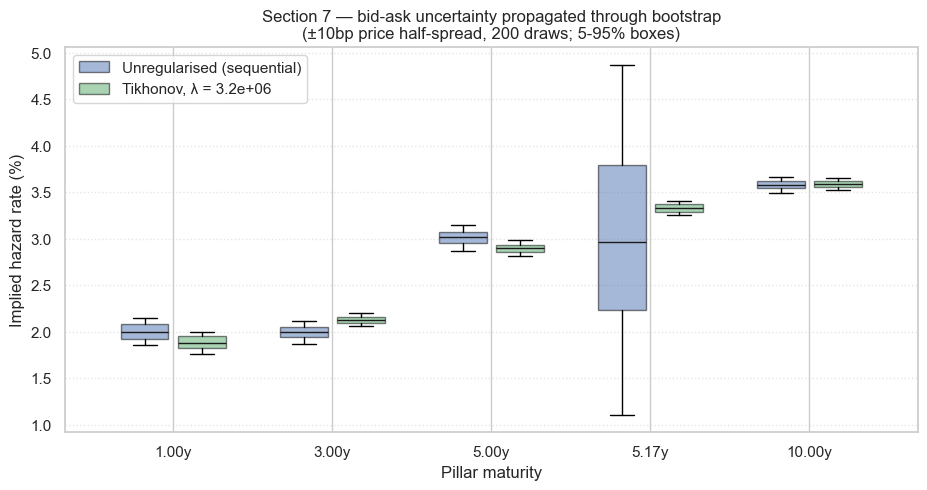

In [18]:
# Box plot per pillar, side by side
fig, axes = create_figure(n_panels=1, figsize=(11, 5))
ax = axes[0]

positions_unreg = np.arange(len(pillar_ts)) - 0.18
positions_reg = np.arange(len(pillar_ts)) + 0.18
labels = [f"{t:.2f}y" for t in pillar_ts]

box1 = ax.boxplot([mc_hazards_unreg[:, i]*100 for i in range(len(pillar_ts))],
                  positions=positions_unreg, widths=0.30, patch_artist=True,
                  boxprops={"facecolor": "C0", "alpha": 0.5},
                  medianprops={"color": "k"},
                  whis=(5, 95), showfliers=False)
box2 = ax.boxplot([mc_hazards_reg[:, i]*100 for i in range(len(pillar_ts))],
                  positions=positions_reg, widths=0.30, patch_artist=True,
                  boxprops={"facecolor": "C2", "alpha": 0.5},
                  medianprops={"color": "k"},
                  whis=(5, 95), showfliers=False)

ax.set_xticks(np.arange(len(pillar_ts)))
ax.set_xticklabels(labels)
ax.set_xlabel("Pillar maturity")
ax.set_ylabel("Implied hazard rate (%)")
ax.set_title(f"Section 7 — bid-ask uncertainty propagated through bootstrap\n"
             f"(±{BID_ASK_HALF_BP}bp price half-spread, {N_MC} draws; 5-95% boxes)")
ax.legend([box1["boxes"][0], box2["boxes"][0]],
          ["Unregularised (sequential)",
           f"Tikhonov, λ = {lam_for_mc:.1e}"], loc="upper left")
ax.grid(True, axis="y", ls=":", alpha=0.5)
fig

**The headline result of Section 7.** Compare the boxes per pillar:

- The two outer pillars (1y, 10y) — far from any close-maturity bunching —
  have similar uncertainty in both methods. ~10 bp of price noise produces
  ~5-20 bp of hazard noise. Regularisation barely helps here because the
  data already constrains those pillars well.
- The close-maturity pillars (3y, 5y, 5.17y) tell the real story. The
  unregularised (blue) boxes are huge — the noise amplification we saw in
  Section 3 is fully visible: 10 bp price noise produces hundreds of bp of
  hazard noise at the close pillars. The Tikhonov boxes (green) are
  *dramatically* narrower at exactly those pillars.

The interpretation: **regularisation isn't just about a smooth-looking
curve. It's about uncertainty quantification.** The unregularised fit has
*honest* but huge uncertainty at the close pillars (the data really don't
constrain those hazards well). The Tikhonov fit reduces apparent uncertainty
by importing a prior — and that prior is empirically grounded as long as
$\lambda$ is picked sensibly (Section 6).

The narrowing is *not* free: the Tikhonov estimate of the close-pillar
hazards is *biased toward the prior's smoothness assumption*. If reality
genuinely has a step change in hazard between 5y and 5y+2mo (e.g. a known
liability cliff), regularised estimates will *under*-represent it. As with
all priors, the user must understand what the prior assumes.